In [1]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime
import matplotlib.pyplot as plt

# Set display options to see more data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully!
Pandas version: 2.2.3


In [2]:
# Path to my file
file_path = '/Users/abyudhka/Desktop/Project/australian-labor-market-analysis/Data/Raw/6202001.xlsx'

# See what sheets are in the file
excel_file = pd.ExcelFile(file_path)
print("Available sheets:")
for i, sheet in enumerate(excel_file.sheet_names, 1):
    print(f"  {i}. {sheet}")

Available sheets:
  1. Index
  2. Data1
  3. Enquiries


In [3]:
# Load Index sheet
df_index = pd.read_excel(file_path, sheet_name='Index')

# Display first 20 rows
print("Index sheet structure:")
print(df_index.head(20))

Index sheet structure:
                           Unnamed: 0  \
0                                 NaN   
1                                 NaN   
2                                 NaN   
3                                 NaN   
4                                 NaN   
5                                 NaN   
6                                 NaN   
7                                 NaN   
8               Data Item Description   
9                                 NaN   
10        Employed total ;  Persons ;   
11        Employed total ;  Persons ;   
12        Employed total ;  Persons ;   
13        Employed total ;  > Males ;   
14        Employed total ;  > Males ;   
15        Employed total ;  > Males ;   
16      Employed total ;  > Females ;   
17      Employed total ;  > Females ;   
18      Employed total ;  > Females ;   
19  > Employed full-time ;  Persons ;   

                                           Unnamed: 1  Unnamed: 2  \
0                                Time Series W

In [4]:
# Load first 15 rows with no header to see raw structure
df_raw = pd.read_excel(file_path, sheet_name='Data1', nrows=15, header=None)

print("Data1 sheet - Raw structure:")
print(df_raw)

print("\nRow 0 (first row):")
print(df_raw.iloc[0])

Data1 sheet - Raw structure:
                    0                            1    \
0                   NaN  Employed total ;  Persons ;   
1                  Unit                          000   
2           Series Type                        Trend   
3             Data Type                        STOCK   
4             Frequency                        Month   
5      Collection Month                            1   
6          Series Start          1978-02-01 00:00:00   
7            Series End          2025-12-01 00:00:00   
8               No. Obs                          575   
9             Series ID                   A84423127L   
10  1978-02-01 00:00:00                  6008.257614   
11  1978-03-01 00:00:00                  6015.169146   
12  1978-04-01 00:00:00                  6021.592387   
13  1978-05-01 00:00:00                  6027.277301   
14  1978-06-01 00:00:00                  6031.343757   

                            2                            3    \
0   Employ

In [5]:
# Load Data1 sheet, treating first 10 rows as header info
df_data = pd.read_excel(file_path, sheet_name='Data1')

print("Shape:", df_data.shape)
print("\nColumn names:")
print(df_data.columns[:10])  # First 10 columns
print("\nFirst few rows:")
print(df_data.head())

Shape: (584, 115)

Column names:
Index(['Unnamed: 0', 'Employed total ;  Persons ;',
       'Employed total ;  Persons ;.1', 'Employed total ;  Persons ;.2',
       'Employed total ;  > Males ;', 'Employed total ;  > Males ;.1',
       'Employed total ;  > Males ;.2', 'Employed total ;  > Females ;',
       'Employed total ;  > Females ;.1', 'Employed total ;  > Females ;.2'],
      dtype='object')

First few rows:
         Unnamed: 0 Employed total ;  Persons ; Employed total ;  Persons ;.1  \
0              Unit                         000                           000   
1       Series Type                       Trend           Seasonally Adjusted   
2         Data Type                       STOCK                         STOCK   
3         Frequency                       Month                         Month   
4  Collection Month                           1                             1   

  Employed total ;  Persons ;.2 Employed total ;  > Males ;  \
0                           000

In [6]:
# Load Index to create a mapping
df_index_full = pd.read_excel(file_path, sheet_name='Index')

# Create mapping: Series ID -> Description
# Find the row where actual data starts (usually row with "Series ID" header)
header_row = df_index_full[df_index_full.iloc[:, 0].astype(str).str.contains('Data Item Description', case=False, na=False)].index[0]

# Load Index with correct header and strip whitespace
df_index_clean = pd.read_excel(file_path, sheet_name='Index', header=header_row + 1)
df_index_clean.columns = df_index_clean.columns.str.strip()

# Create series mapping dictionary
series_mapping = dict(zip(df_index_clean['Series ID'], df_index_clean['Data Item Description']))

print("Sample mappings:")
for series_id, description in list(series_mapping.items())[:5]:
    print(f"{series_id}: {description}")

Sample mappings:
nan: © Commonwealth of Australia  2026
A84423127L: Employed total ;  Persons ;
A84423043C: Employed total ;  Persons ;
A84423085A: Employed total ;  Persons ;
A84423113X: Employed total ;  > Males ;


In [7]:
## Clean stray metadeta
series_mapping = {k: v for k, v in series_mapping.items() if str(k) != 'nan'}

In [8]:
# Filter index for Seasonally Adjusted series
df_index_sa = df_index_clean[df_index_clean['Series Type'] == 'Seasonally Adjusted'].copy()

print(f"Total Seasonally Adjusted series: {len(df_index_sa)}")

# Look for key metrics
key_metrics = ['Employed total', 'Unemployed total', 'Unemployment rate', 
               'Participation rate', 'Labour force total']

# Find Series IDs for these metrics (Persons, not Male/Female)
selected_series = {}

for metric in key_metrics:
    # Find series that match this metric and are for "Persons" (not gender-specific)
    matches = df_index_sa[
        (df_index_sa['Data Item Description'].str.contains(metric, case=False, na=False)) &
        (df_index_sa['Data Item Description'].str.contains('Persons', case=False, na=False))
    ]
    
    if len(matches) > 0:
        series_id = matches.iloc[0]['Series ID']
        selected_series[metric] = series_id ## add to dictonary
        print(f"{metric}: {series_id}")
    else:
        print(f"{metric}: NOT FOUND")

print(f"\nTotal selected series: {len(selected_series)}")

Total Seasonally Adjusted series: 36
Employed total: A84423043C
Unemployed total: A84423046K
Unemployment rate: A84423050A
Participation rate: A84423051C
Labour force total: A84423047L

Total selected series: 5


In [9]:
### Extract Data for Selected Series
# The Data1 sheet has Series IDs as column names and dates in first column
# We need to:
# 1. Get the date column
# 2. Get the columns for our selected series
# 3. Reshape to long format

# First, let's understand the Data1 structure better
df_data_raw = pd.read_excel(file_path, sheet_name='Data1', header=None)

# Find where the Series IDs are (usually row 9)
series_id_row = 9
date_col_index = 0

# Extract dates (first column, starting from row 10)
dates = df_data_raw.iloc[10:, date_col_index]

# Find column indices for our selected series
# The Series IDs are in row 9
series_id_headers = df_data_raw.iloc[series_id_row, :]

# Create a dataframe to hold our cleaned data
data_dict = {'date': dates.values}

# For each selected series, find its column and extract data
for metric_name, series_id in selected_series.items():
    # Find which column has this Series ID
    col_index = series_id_headers[series_id_headers == series_id].index
    
    if len(col_index) > 0:
        col_index = col_index[0]
        # Extract data from row 10 onwards
        data_values = df_data_raw.iloc[10:, col_index].values
        data_dict[metric_name] = data_values
        print(f" Extracted {metric_name}")
    else:
        print(f" Could not find column for {series_id}")

# Create DataFrame
df_clean = pd.DataFrame(data_dict)

print("\n Cleaned data shape:", df_clean.shape)
print("\nFirst few rows:")
print(df_clean.head())

 Extracted Employed total
 Extracted Unemployed total
 Extracted Unemployment rate
 Extracted Participation rate
 Extracted Labour force total

 Cleaned data shape: (575, 6)

First few rows:
        date Employed total Unemployed total Unemployment rate  \
0 1978-02-01    5997.714047       426.881162          6.644483   
1 1978-03-01    6003.236606       403.814174          6.302653   
2 1978-04-01    6030.876194       403.248568          6.267341   
3 1978-05-01    6033.227088       399.429461          6.209401   
4 1978-06-01    6033.949901        405.96681          6.303914   

  Participation rate Labour force total  
0          61.248862        6424.595209  
1          60.969357         6407.05078  
2          61.168637        6434.124761  
3          61.084965        6432.656549  
4          61.080226         6439.91671  


In [11]:
# Step 1: Convert date column to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Step 2: Sort by date
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# Step 3: Filter for 2019 onwards (to show COVID impact)
df_clean = df_clean[df_clean['date'] >= '2019-01-01'].copy()

# Step 4: Convert numeric columns from thousands to actual numbers
# Check if values are in thousands (they usually are in ABS data)
numeric_cols = ['Employed total', 'Unemployed total', 'Labour force total']

for col in numeric_cols:
    if col in df_clean.columns:
        # Convert to numeric first (in case there are any strings)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        # Multiply by 1000 (ABS reports in thousands)
        df_clean[col] = df_clean[col] * 1000
        # Convert to integer
        df_clean[col] = df_clean[col].round(0).astype('Int64')  # Int64 allows NaN values

# Step 5: Ensure percentage columns are numeric
percentage_cols = ['Unemployment rate', 'Participation rate']
for col in percentage_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Step 6: Rename columns to SQL-friendly names (lowercase, underscores)
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

print(" Data cleaned!")
print(f"\nDate range: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"Total rows: {len(df_clean)}")
print(f"\nColumns: {list(df_clean.columns)}")
print("\nFirst few rows:")
print(df_clean.head())
print("\nLast few rows:")
print(df_clean.tail())

 Data cleaned!

Date range: 2019-01-01 00:00:00 to 2025-12-01 00:00:00
Total rows: 84

Columns: ['date', 'employed_total', 'unemployed_total', 'unemployment_rate', 'participation_rate', 'labour_force_total']

First few rows:
        date  employed_total  unemployed_total  unemployment_rate  \
0 2019-01-01        12715762            676119           5.048726   
1 2019-02-01        12729930            668701           4.990817   
2 2019-03-01        12749056            684099           5.092615   
3 2019-04-01        12785354            704470           5.222230   
4 2019-05-01        12791482            700914           5.194882   

   participation_rate  labour_force_total  
0           65.609269            13391881  
1           65.529498            13398632  
2           65.585595            13433155  
3           65.798123            13489824  
4           65.746620            13492396  

Last few rows:
         date  employed_total  unemployed_total  unemployment_rate  \
79 2025-08

In [14]:
### Perform quality checks
# Quality checks
print("="*60)
print("QUALITY CHECKS")
print("="*60)

# Check 1: Missing values
print("\n1. Missing values:")
print(df_clean.isnull().sum())

# Check 2: Data types
print("\n2. Data types:")
print(df_clean.dtypes)

# Check 3: Value ranges (ensure no negatives)
print("\n3. Value ranges:")
print(df_clean.describe())

# Check 4: Check for duplicates
duplicates = df_clean.duplicated(subset=['date']).sum()
print(f"\n4. Duplicate dates: {duplicates}")

# Check 5: Date continuity (are there missing months?)
date_range = pd.date_range(start=df_clean['date'].min(), 
                           end=df_clean['date'].max(), 
                           freq='MS')  # Month Start frequency
missing_dates = set(date_range) - set(df_clean['date'])
print(f"\n5. Missing months: {len(missing_dates)}")
if len(missing_dates) > 0 and len(missing_dates) < 10:
    print(f"   Missing: {sorted(missing_dates)}")

# Check 6: Reasonable values
print("\n6. Latest values (sanity check):")
latest = df_clean.iloc[-1]
print(f"   Date: {latest['date']}")
print(f"   Employed total: {latest['employed_total']:,.0f}")
print(f"   Unemployment rate: {latest['unemployment_rate']:.1f}%")

print("\n Quality checks complete!")

QUALITY CHECKS

1. Missing values:
date                  0
employed_total        0
unemployed_total      0
unemployment_rate     0
participation_rate    0
labour_force_total    0
dtype: int64

2. Data types:
date                  datetime64[ns]
employed_total                 Int64
unemployed_total               Int64
unemployment_rate            float64
participation_rate           float64
labour_force_total             Int64
dtype: object

3. Value ranges:
                                date   employed_total  unemployed_total  \
count                             84             84.0              84.0   
mean   2022-06-16 14:17:08.571428608  13558939.619048     653523.333333   
min              2019-01-01 00:00:00       12049922.0          486097.0   
25%              2020-09-23 12:00:00       12881089.0          560031.0   
50%              2022-06-16 00:00:00       13587668.0          627186.0   
75%              2024-03-08 18:00:00       14251846.5          704749.0   
max          

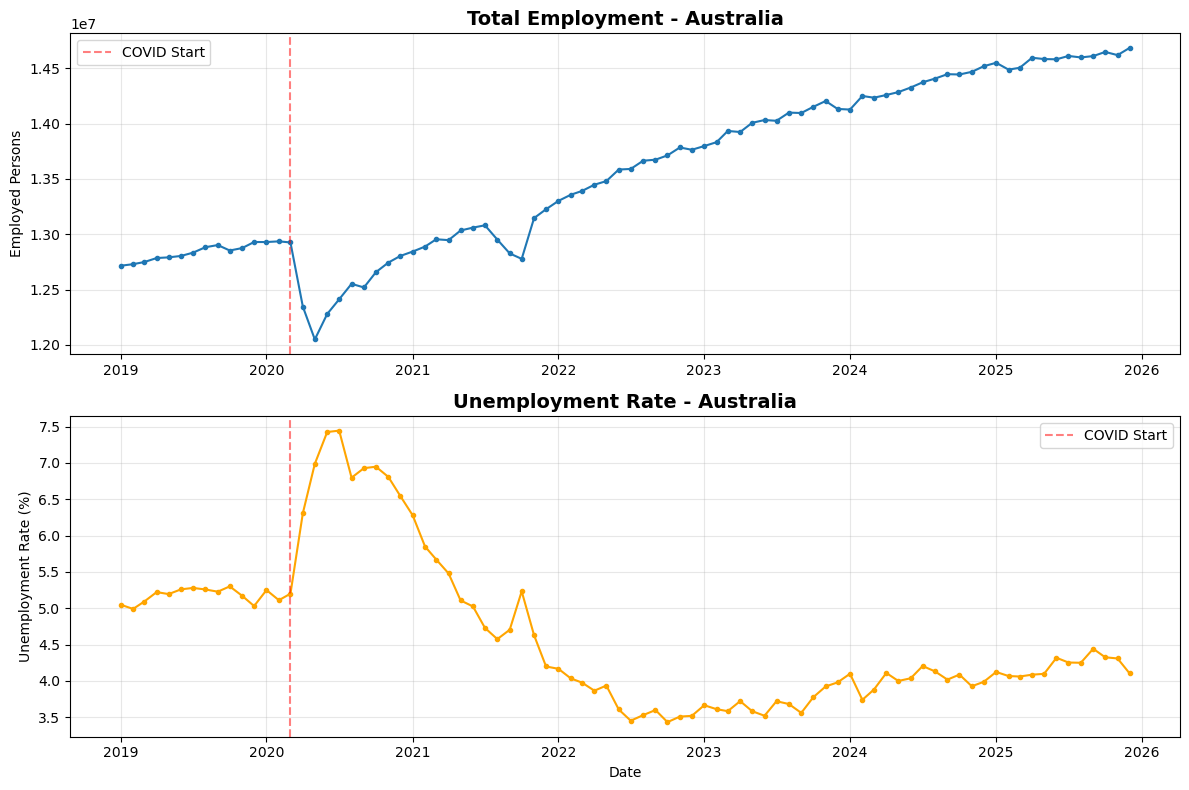

 If the charts show COVID spike in unemployment (2020), data is correct!


In [15]:
### Visualization verification
# Create a simple visualization to verify data looks correct
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Employment over time
axes[0].plot(df_clean['date'], df_clean['employed_total'], marker='o', markersize=3)
axes[0].set_title('Total Employment - Australia', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Employed Persons')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=pd.to_datetime('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
axes[0].legend()

# Plot 2: Unemployment rate
axes[1].plot(df_clean['date'], df_clean['unemployment_rate'], marker='o', markersize=3, color='orange')
axes[1].set_title('Unemployment Rate - Australia', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=pd.to_datetime('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID Start')
axes[1].legend()

plt.tight_layout()
plt.show()

print(" If the charts show COVID spike in unemployment (2020), data is correct!")

In [19]:
### Save the cleaned dataset
# Save to processed folder
output_path = '/Users/abyudhka/Desktop/Project/australian-labor-market-analysis/Data/processed/employment_trends_national.csv'

df_clean.to_csv(output_path, index=False)

print(f" Saved to: {output_path}")
print(f"   Rows: {len(df_clean)}")
print(f"   Columns: {len(df_clean.columns)}")

# Verify by reading back
df_test = pd.read_csv(output_path)
print(f"\n Verification: Successfully read back {len(df_test)} rows")
print("\nFile preview:")
print(df_test.head())

 Saved to: /Users/abyudhka/Desktop/Project/australian-labor-market-analysis/Data/processed/employment_trends_national.csv
   Rows: 84
   Columns: 6

 Verification: Successfully read back 84 rows

File preview:
         date  employed_total  unemployed_total  unemployment_rate  \
0  2019-01-01        12715762            676119           5.048726   
1  2019-02-01        12729930            668701           4.990817   
2  2019-03-01        12749056            684099           5.092615   
3  2019-04-01        12785354            704470           5.222230   
4  2019-05-01        12791482            700914           5.194882   

   participation_rate  labour_force_total  
0           65.609269            13391881  
1           65.529498            13398632  
2           65.585595            13433155  
3           65.798123            13489824  
4           65.746620            13492396  
